# DAY 5
# DATE - 22.05.2026
# Radiometric + Atmospheric Correction

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def convert_dn_to_toa(dn_array):
  """
  Converts raw Sentinel - 2 Digital Numbers (DN)
  to Top of Atmosphere (TOA) reflectance.
  """
  SCALE_FACTOR = 10000.0
  return dn_array / SCALE_FACTOR

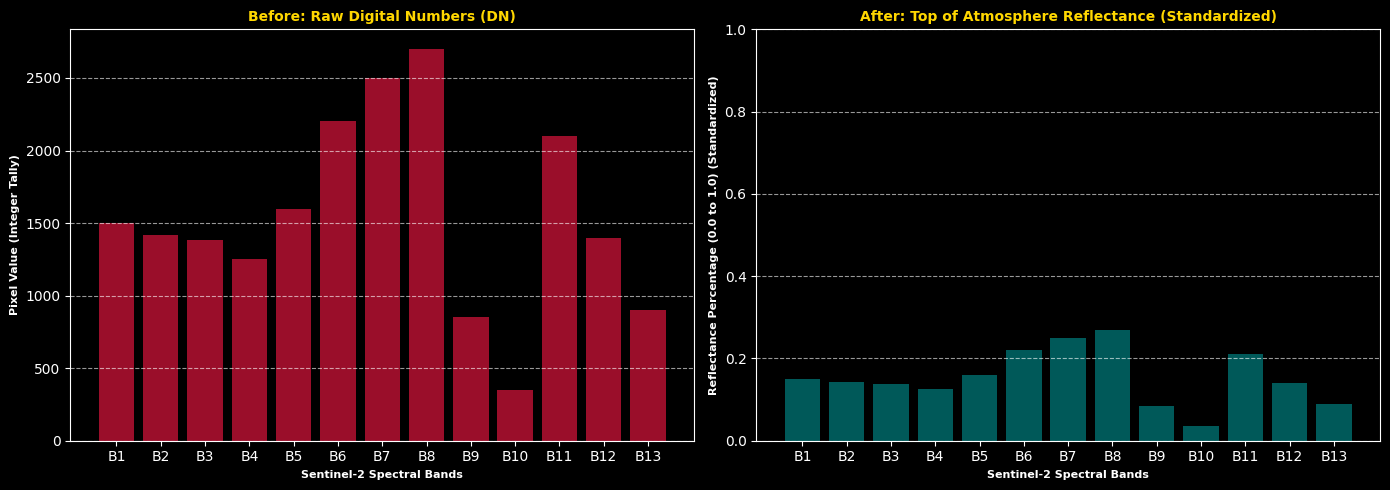

In [9]:
# 1. Setup mock raw DN values for the 13 Sentinel-2 bands
# Bright bands (like clouds/snow or bright soils) have higher DN values.

plt.style.use('dark_background')

raw_dn_bands = np.array([
    1500, 1420, 1380, 1250, 1600, 2200, 2500, 2700, 850, 350, 2100, 1400, 900
])
band_names = [f"B{i}" for i in range(1, 14)]

# 2. Run the conversion function

toa_reflectance = convert_dn_to_toa(raw_dn_bands)

# 3. Plot the Before (DN) vs After (TOA) comparison

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

# Plot Before: Raw DN

ax1.bar(band_names, raw_dn_bands, color = 'crimson', alpha = 0.7)
ax1.set_title('Before: Raw Digital Numbers (DN)', color = 'gold', fontweight = 'bold', fontsize = 10)
ax1.set_xlabel('Sentinel-2 Spectral Bands', color = 'white', fontweight = 'bold', fontsize = 8)
ax1.set_ylabel('Pixel Value (Integer Tally)', color = 'white', fontweight = 'bold', fontsize = 8)
ax1.grid(axis = 'y', linestyle = '--', alpha = 0.6)

# Plot After: TOA Reflectance

ax2.bar(band_names, toa_reflectance, color = 'teal', alpha = 0.7)
ax2.set_title('After: Top of Atmosphere Reflectance (Standardized)', color = 'gold', fontweight = 'bold', fontsize = 10)
ax2.set_xlabel('Sentinel-2 Spectral Bands', color = 'white', fontweight = 'bold', fontsize = 8)
ax2.set_ylabel('Reflectance Percentage (0.0 to 1.0) (Standardized)', color = 'white', fontweight = 'bold', fontsize = 8)
ax2.set_ylim(0, 1.0)
ax2.grid(axis = 'y', linestyle = '--', alpha = 0.6)

plt.tight_layout()
plt.show()